In [ ]:
# TASKS
# 1. Given the business problem “Detecting unusual (potentially fraudulent) purchase
# transactions.”, what can be some key performance indicators (KPI) for evaluating the
# system performance? Articulate your rationale for selecting such KPI?

# 2. Read the data and perform Exploratory Data Analysis. What are some key insights from
# your exploration? Clean the data and perform preprocessing e.g. handling missing values
# and outliers, encoding the columns by converting categories to numbers, or multiple
# columns. If needed engineer additional features.

# 3. Using statistical test or other feature selection methods, select relevant features. Justify
# the selection based on interpretability or impact.

# 4. Build and train the following machine learning models (80% of the overall data):
#   a. Decision Tree
#   b. Logistic Regression
#   c. Naïve Bayes

# 5. Evaluate the models (20% of the overall data not used in training) and determine the
# metrics of interest.

# 6. Compare the models. Discuss trade-offs between models. Recommend the most
# suitable model for production deployment.

# 7. Discuss the following questions:
#   a. Risks of bias in model predictions. Suggest ideas to mitigate such risks.
#   b. How customer privacy is preserved, especially with encoded data.
#   c. Reflect on any steps taken to mitigate potential ethical issues.

# CIS 518 TASKS
# 8. In task 4, while building the models, tune different hyperparameters for the models. Use
# grid search (e.g. GridSearchCV or RandomizedSearchCV) with cross validation.

# 9. Is it possible to build system with better performance? If so, how?

###############################################################################
# Codebase:
# • Clean, well-commented Python code (organized into notebooks or scripts).
# • Clear folder structure (e.g., data/, src/, outputs/).
# • README describing how to run your solution.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
file_path = '../data/Online_transaction_data.csv'
df = pd.read_csv(file_path)

In [6]:
df.describe(include='all')

,Transaction Time,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,...,PCA21,PCA22,PCA23,PCA24,PCA25,PCA26,PCA27,PCA28,Amount,Type_of_Transaction
count,284807.000000,2.848070e+05,2.848070e+05,284805.000000,284806.000000,2.848070e+05,284805.000000,2.848070e+05,284804.000000,284797.000000,...,2.848050e+05,2.848060e+05,284806.000000,2.848060e+05,2.848070e+05,2.848070e+05,2.848060e+05,2.848060e+05,284807.000000,284807
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,284315
mean,94813.859575,1.759061e-12,-8.251130e-13,-0.000012,-0.000001,1.649999e-13,-0.000009,-3.054600e-13,0.000006,0.000002,...,4.184317e-07,-2.594777e-07,0.000001,-3.848964e-07,-6.987102e-13,-5.617874e-13,3.156142e-07,-1.559143e-07,88.349619,NaN
std,47488.145955,1.958696e+00,1.651309e+00,1.516254,1.415871,1.380247e+00,1.332261,1.237094e+00,1.194356,1.098628,...,7.345266e-01,7.257028e-01,0.624461,6.056481e-01,5.212781e-01,4.822270e-01,4.036332e-01,3.300838e-01,250.120109,NaN
min,0.000000,-5.640751e+01,-7.271573e+01,-48.325589,-5.683171,-1.137433e+02,-26.160506,-4.355724e+01,-73.216718,-13.434066,...,-3.483038e+01,-1.093314e+01,-44.807735,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,NaN
25%,54201.500000,-9.203734e-01,-5.985499e-01,-0.890372,-0.848642,-6.915971e-01,-0.768296,-5.540759e-01,-0.208629,-0.643096,...,-2.283999e-01,-5.423514e-01,-0.161846,-3.545895e-01,-3.171451e-01,-3.269839e-01,-7.083937e-02,-5.295995e-02,5.600000,NaN
50%,84692.000000,1.810880e-02,6.548556e-02,0.179845,-0.019848,-5.433583e-02,-0.274187,4.010308e-02,0.022359,-0.051436,...,-2.944510e-02,6.781490e-03,-0.011193,4.097377e-02,1.659350e-02,-5.213911e-02,1.342244e-03,1.124381e-02,22.000000,NaN
75%,139320.500000,1.315642e+00,8.037239e-01,1.027167,0.743348,6.119264e-01,0.398560,5.704361e-01,0.327347,0.597140,...,1.863843e-01,5.285544e-01,0.147642,4.395270e-01,3.507156e-01,2.409522e-01,9.104579e-02,7.828043e-02,77.165000,NaN


In [7]:
# Initial 5 rows in data
df.head(5)

,Transaction Time,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,...,PCA21,PCA22,PCA23,PCA24,PCA25,PCA26,PCA27,PCA28,Amount,Type_of_Transaction
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,Normal
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,Normal
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,Normal
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,Normal
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,Normal


Let's see how many null values we have in the dataset. If it's not that much, removing those entries won't do much harm for us.

In [8]:
# check for null values
df.isnull().sum()

Transaction Time        0
PCA1                    0
PCA2                    0
PCA3                    2
PCA4                    1
PCA5                    0
PCA6                    2
PCA7                    0
PCA8                    3
PCA9                   10
PCA10                   2
PCA11                   0
PCA12                   4
PCA13                   3
PCA14                   1
PCA15                   3
PCA16                   1
PCA17                   4
PCA18                   2
PCA19                  12
PCA20                   2
PCA21                   2
PCA22                   1
PCA23                   1
PCA24                   1
PCA25                   0
PCA26                   0
PCA27                   1
PCA28                   1
Amount                  0
Type_of_Transaction     0
dtype: int64

In [9]:
# drop all the rows with null values
df = df.dropna()
df.isnull().sum()

Transaction Time       0
PCA1                   0
PCA2                   0
PCA3                   0
PCA4                   0
PCA5                   0
PCA6                   0
PCA7                   0
PCA8                   0
PCA9                   0
PCA10                  0
PCA11                  0
PCA12                  0
PCA13                  0
PCA14                  0
PCA15                  0
PCA16                  0
PCA17                  0
PCA18                  0
PCA19                  0
PCA20                  0
PCA21                  0
PCA22                  0
PCA23                  0
PCA24                  0
PCA25                  0
PCA26                  0
PCA27                  0
PCA28                  0
Amount                 0
Type_of_Transaction    0
dtype: int64

In [10]:
# rows after dropping null rows
len(df)

284748

In [11]:
# replace 'Normal' and 'Unusual' with '0' and '1'
#df['Type_of_Transaction'].replace({'Unusual':1, 'Normal':0}, inplace=True)
df['Type_of_Transaction'] = df['Type_of_Transaction'].map({'Normal': 0, 'Unusual': 1})
df

,Transaction Time,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,...,PCA21,PCA22,PCA23,PCA24,PCA25,PCA26,PCA27,PCA28,Amount,Type_of_Transaction
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [12]:
# How many of each transaction exists.
df['Type_of_Transaction'].value_counts()

Type_of_Transaction
0    284256
1       492
Name: count, dtype: int64

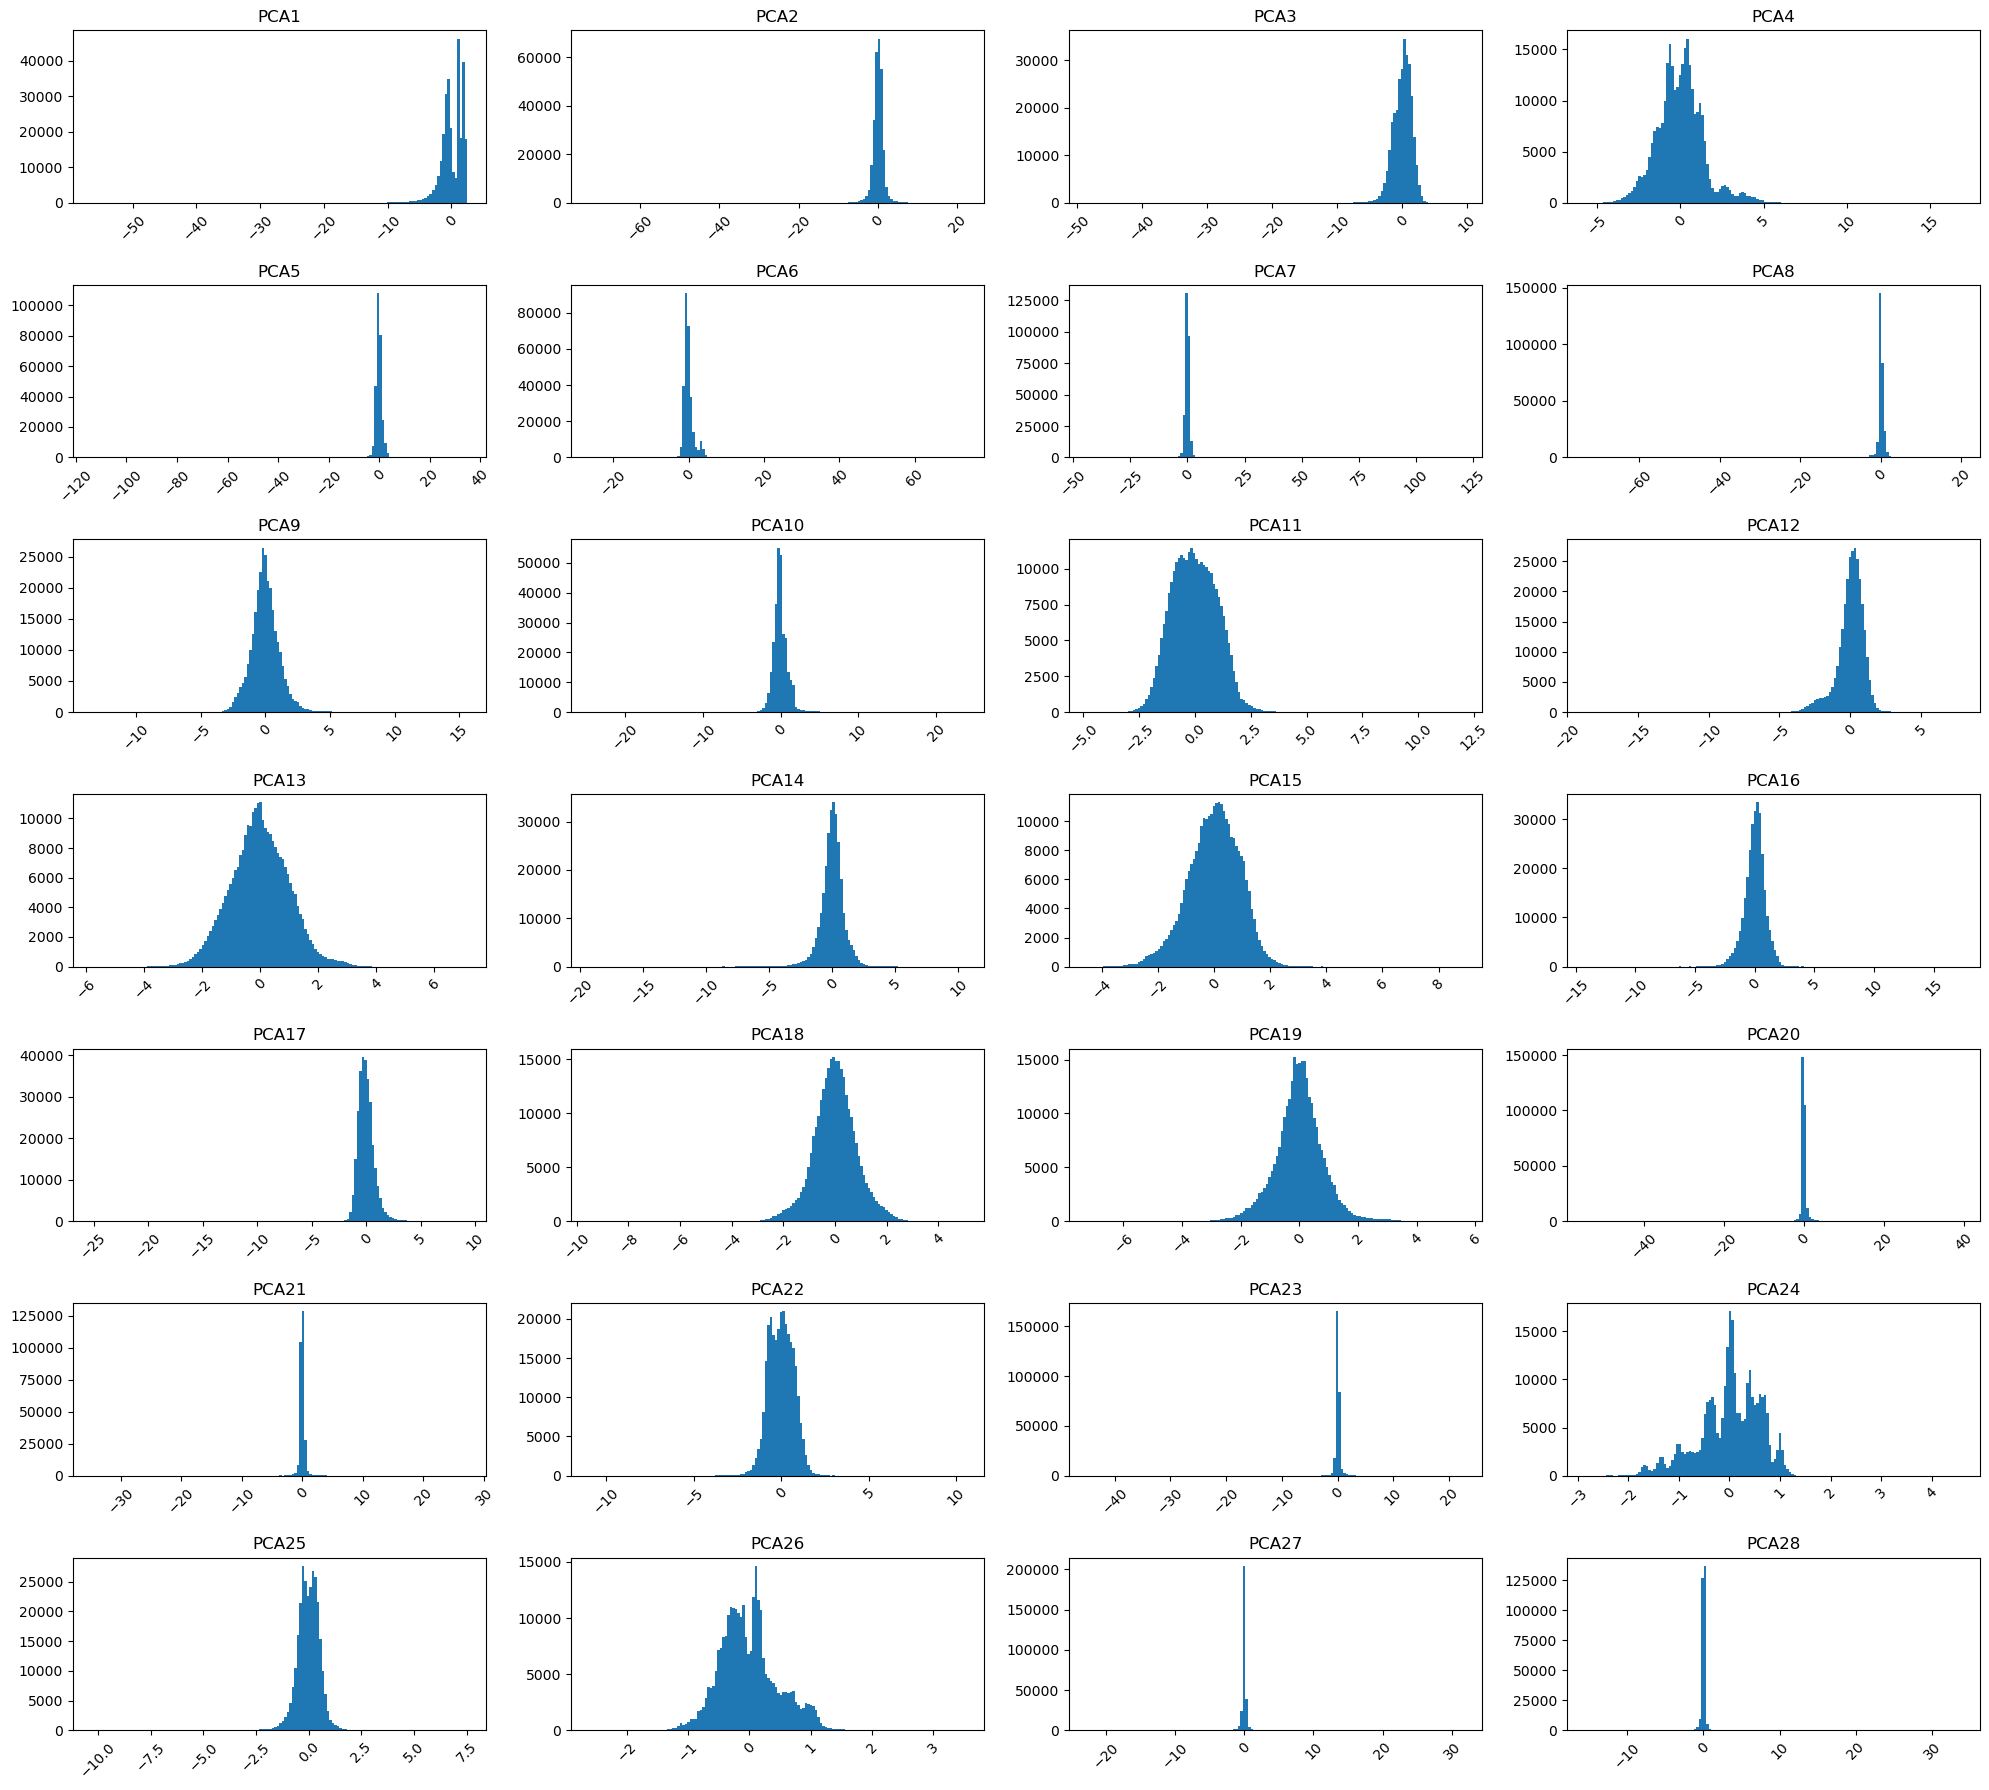

In [13]:
pca_columns = [f'PCA{i}' for i in range(1, 29)]

fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(pca_columns):
    axes[i].hist(df[col], bins=150)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

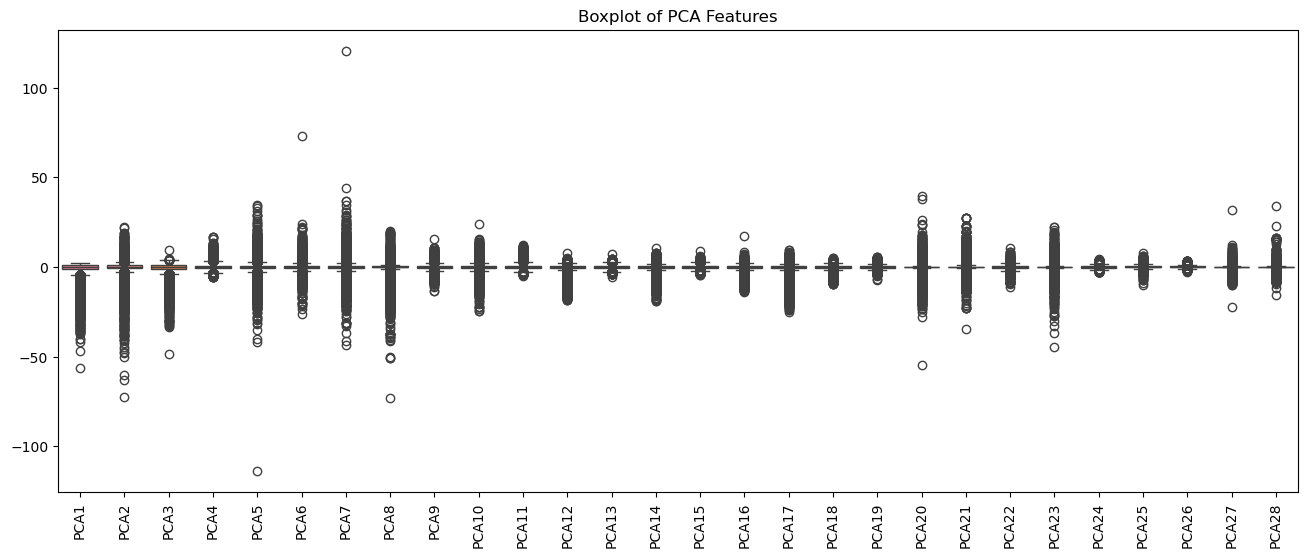

In [14]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df.iloc[:, 1:29])
plt.xticks(rotation=90)
plt.title("Boxplot of PCA Features")
plt.show()

count    284748.000000
mean         88.354813
std         250.135898
min           0.000000
25%           5.600000
50%          22.000000
75%          77.190000
max       25691.160000
Name: Amount, dtype: float64


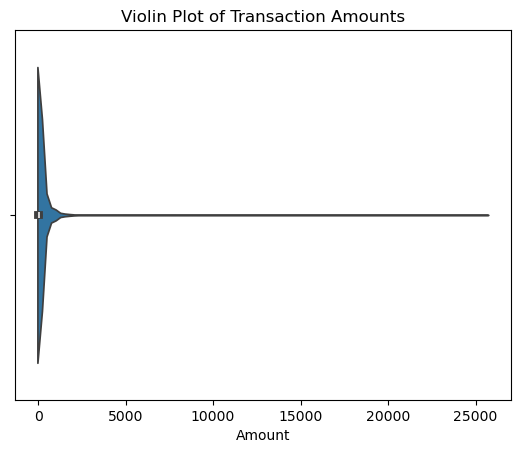

In [15]:
print(df['Amount'].describe())

import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x=df['Amount'])
plt.xlabel('Amount')
plt.title('Violin Plot of Transaction Amounts')
plt.show()

As we can see, the data in Amount column is highly distributed. Difference between Mean and Max value is large. If we are to use this column for model training, it is important for the features not to have vastly different scales. This might introduce bias in our model. If this column is selected as one of the important columns, we will have to scale the data.

In [16]:
#avg amount for scam vs ham transaction
df.groupby('Type_of_Transaction')['Amount'].mean()

Type_of_Transaction
0     88.296212
1    122.211321
Name: Amount, dtype: float64

Scam transactions tend to have higher mean value than normal transactions, which makes sense.

In [ ]:
# EXPLORATORY DATA ANALYSIS
# We performed initial EDA when cleaning and preparing the data
# Very few null values (null rows = 59)
# Transactions are only 'Normal' or 'Unusual', needed to be turned into numeric (0, 1)
# Data is highly imbalanced, 284256 'Normal' transactions, 492 'Unusual'
# Histograms show high peaks, particularly PCA5, 6, 7, 8, 20, 21, 23, 27, 28, there are other peaks in some areas but not as apparent
# The boxplots show more obvious outliers and we can start to see them on the peaks that wern't as apparent. But they reaffirm our suspicions of the outlier peaks


In [ ]:
# KEY PERFORMANCE INDICATORS
# ACCURACY
# Accuracy would not be a meaningful KPI as it provides misleading information in case of high class imbalance. There are 284,256 'Normal' transactions and only 492 'Unusual' ones.
# The data is extremely imbalanced, a model that always predicts "Normal" would be 99.83% accurate without ever detecting a single 'Unusual' transaction.

# PRECISION
# Precision would be a good KPI as it tells us out of total transactions that were predicted as 'Unusual', how many were ACTUALLY 'Unusual'.
# 'Unusual' transactions are super rare (0.17% which is less than a quarter of a percent), so even a small number of false positives would significantly lower precision.
# We want to reduce the number of false positives, so precision is key.

# RECALL
# Recall would also be the best KPI because  it measures out of total actual 'Unusual' transactions, how many does the model correctly predicted.
# There's only 492 'Unusual' cases, so getting even a small number wrong would significantly reduce recall. For fraud detection, Recall is an extremely important measure
# because you would want to catch as many fradulent transactions as possible.

# F1 SCORE
# The client wants us to build a model that captures the unsual transactions, because we're not necessarily sure
# which direction they want to go between getting as many as possible or maximizing reducing false positives an F1 score may
# be ideal as it's the sweet spot between the two.

For task 3, we have 3 types of feature selection methods, as discussed in assignment 3; filter method, wrapper method and embedded methods.
Filter methods use statistical tests to evaluate and compare features. These methods are fast but don't account for feature interactions. For quick sense, let's use Mutual Information (MI) method to extract significant features.

Then, let's use an embedded method, random forest model to extract top N features. Embedded method selects features during training and chooses most important features as it learns. It is less computational expensive than wrapper methods and more informed than filter methods.  


In [17]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X = df.drop(columns=['Type_of_Transaction'])
y = df['Type_of_Transaction']

# get MI scores (TOP 10)
selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_new = selector.fit_transform(X, y)

# a mask is boolean that tells which features were selected and which wern't e.g. {True, False, True, True, False...}
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]

print("Top 10 features by Mutual Information:", selected_features)

mi_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print(mi_scores.head(10))

Top 10 features by Mutual Information: Index(['PCA3', 'PCA4', 'PCA9', 'PCA10', 'PCA11', 'PCA12', 'PCA14', 'PCA16',
       'PCA17', 'PCA18'],
      dtype='object')
PCA17    0.008259
PCA14    0.008140
PCA12    0.007605
PCA10    0.007532
PCA11    0.006832
PCA16    0.006145
PCA4     0.004977
PCA3     0.004953
PCA18    0.004318
PCA9     0.004278
dtype: float64


PCA ------ MI Score


---


PCA17 ---   0.008259

PCA14    --- 0.008140

PCA12    --- 0.007605

PCA10    --- 0.007532

PCA11   --- 0.006832

PCA16    --- 0.006145

PCA4     --- 0.004977

PCA3     --- 0.004953

PCA18    --- 0.004318

PCA9     --- 0.004278

Mutual Information scores are low due to a highly imbalanced dataset. PCA components are abstract and represent combinations of original features, so these individual PCA components may not have strong predictive strength alone. Mutual Information helps identify which PCAs contribute the most and should be used together for better model performance


In [18]:
from sklearn.ensemble import RandomForestClassifier

# create random forest model, starting with 100
rf_model = RandomForestClassifier(n_estimators=100, random_state=1337)

# recreate our features and target
X = df.drop(columns=['Type_of_Transaction'])
y = df['Type_of_Transaction']

# fit the model
rf_model.fit(X, y)

# grab the feature importances (feature importance measures how much each feature helped reduce Gini impurity across the forest. Essentially how often each time a feature helped make an informative split)
importances = rf_model.feature_importances_

# populate a series with the info
feature_importance_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# display the feature importance
print(feature_importance_series.head(10))

PCA17    0.175585
PCA12    0.150412
PCA14    0.101011
PCA11    0.077850
PCA10    0.077545
PCA16    0.050785
PCA9     0.031937
PCA4     0.031758
PCA18    0.024727
PCA7     0.022969
dtype: float64


PCA --- Importance Score


---


PCA17 ---   0.175544

PCA12 ---   0.150400

PCA14  ---  0.101547

PCA11 ---   0.078006

PCA10  ---  0.077559

PCA16  ---  0.050656

PCA9  ---   0.032015

PCA4  ---   0.031806

PCA18 ---   0.024748

PCA7  ---   0.022887

As you can see the importance scores similarly match the Mutual information scores seen above.

In [19]:
# Selecting important features for training
important_features = ['PCA17', 'PCA12', 'PCA14', 'PCA11', 'PCA10', 'PCA16', 'PCA9', 'PCA4', 'PCA18', 'PCA7']
X = df[important_features]
y = df['Type_of_Transaction']


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


In [21]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(227798, 10) (56950, 10) (227798,) (56950,)


In [22]:
output_folder = '../output/'

Training Descision trees

In [24]:
# hyper parameter tuning for descision trees
from sklearn.tree import DecisionTreeClassifier
import os
model = DecisionTreeClassifier()
param_grid = {'max_depth': [5, 10, 15, 20],
              'min_samples_split': [2, 5, 7],
              'min_samples_leaf': [1, 2, 5, 10],
              'criterion': ['gini', 'entropy']}


grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(best_params)

best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)

decision_tree_output = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
decision_tree_output.to_csv(os.path.join(output_folder, 'decision_tree_predictions.csv'), index=False)


# Evaluation metrics
print(classification_report(y_test, y_pred))

# Confusion Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.90      0.85      0.88        87

    accuracy                           1.00     56950
   macro avg       0.95      0.93      0.94     56950
weighted avg       1.00      1.00      1.00     56950

Confusion Matrix:
 [[56855     8]
 [   13    74]]


Training Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], # Logarithmic scale often good for C
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'] # Solvers compatible with both l1 and l2
}

grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, n_jobs=-1, verbose=2)
grid_search_lr.fit(X_train, y_train)

# Best Parameters
best_params_lr = grid_search_lr.best_params_
print("Best Parameters:\n", best_params_lr)

best_lr = grid_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

# Save Logistic Regression predictions
logistic_regression_output = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_lr
})
logistic_regression_output.to_csv(os.path.join(output_folder, 'logistic_regression_predictions.csv'), index=False)


# Evaluation metrics
print(classification_report(y_test, y_pred_lr))

# Confusion Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
 {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.87      0.62      0.72        87

    accuracy                           1.00     56950
   macro avg       0.94      0.81      0.86     56950
weighted avg       1.00      1.00      1.00     56950

Confusion Matrix:
 [[56855     8]
 [   33    54]]


Naive Bayes Training

In [27]:
from sklearn.naive_bayes import GaussianNB
nb_classifier = GaussianNB()

# Define the hyperparameter grid to search
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Smoothing parameter
}

grid_search_nb = GridSearchCV(
    estimator=nb_classifier,
    param_grid=param_grid_nb,
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1  # Print progress
)

grid_search_nb.fit(X_train, y_train)

# Best Parameters
best_params_nb = grid_search_nb.best_params_
print("Best Parameters:\n", best_params_nb)

best_nb = grid_search_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test)

# Save Naive Bayes predictions
naive_bayes_output = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_nb
})
naive_bayes_output.to_csv(os.path.join(output_folder, 'naive_bayes_predictions.csv'), index=False)

# Evaluation metrics
print(classification_report(y_test, y_pred_nb))

#Confusion Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters:
 {'var_smoothing': 1e-09}
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56863
           1       0.14      0.90      0.24        87

    accuracy                           0.99     56950
   macro avg       0.57      0.94      0.62     56950
weighted avg       1.00      0.99      0.99     56950

Confusion Matrix:
 [[56385   478]
 [    9    78]]


After training and evaluating the models we were given data of the performance of each one.

**Decision Trees:**
*   Precision: 90%
*   Recall: 85%
*   f1-score: 88%

Confusion Matrix:
*   True Positive: 74
*   False Positive: 8
*   False Negative: 13
*   True Negative: 56855

Sumamry:
*   Caught 85% of all fraudulent transactions
*   8 false positives (remember: FP = normal transactions marked as fraud)
*   13 fraud transactions marked as normal.




**Naive Bayes:**
*   Precision: 14%
*   Recall: 90%
*   f1-score: 24%

Confusion Matrix:
*   True Positive: 78
*   False Positive: 478
*   False Negative: 9
*   True Negative: 56385

Sumamry:
*   Caught 90% of all fraudulent transactions
*   478 False Positives
*   Precision was 14%, which shows with the very high amount of false positives

**Logistic Regression:**
*   Precision: 87%
*   Recall: 62%
*   f1-score: 72%

Confusion Matrix:
*   True Positive: 54
*   False Positive: 8
*   False Negative: 33
*   True Negative: 56855

Sumamry:
*   Caught 62% of all fraudulent transactions
*   8 False Positives
* 33 False Negatives (fraud transactions marked as normal)


Take Away:
*   Decision Tree had the best balance between precision and recall, resulting in a high f1-score.
* Naive Bayes had highest recall but had extremely low precision, it picked up too much noise and suffered heavily from it by producing too many false alarms
*  Logistic Regression had slightly lower precision compared to Decision Trees but missed a significant amount of fraudulent transactions, resulting in the seen lower recall

Overall, Decision Trees was the best model out of these three based on the data it was trained on and the results it produced. It was able to accurately identify the transactions while also limiting the false positives.







